Title: Rsds_mean_and_anomaly.ipynb

Purpose: Calculate a model mean and the rsds anomaly data

Author: Onno Nennecke on 02.06.2025 Modified: 08.10.2025

Input data: 

- rsds Data from ERA5 and CMIP
    - These files lie here: /climca/people/onennecke/not_debiased_data/
- Used Runs File: CMIP6_runs.csv
    - These files lie here: /home/onennecke/CMIP_models/

Output data:

- rsds winter means Data: rsds_mean_combined.nc
    - This file lies here: /climca/people/onennecke/model_output/var_means/Rsds_not_bc/
- rsds Anomaly Data
    - This file lies here: /climca/people/onennecke/model_output/rsds_anomaly/not_bc/
- rsds composite data
    - This file lies here: //climca/people/onennecke/model_output/composites

### Load libraries and functions

In [1]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import os
import glob
import time
# import cftime
import re

# Importing functions
import Functions.grid_func as grid_func

/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/esmpy/interface/loadESMF.py:94: VersionWarning: ESMF installation version 8.8.0, ESMPy version 8.8.0b0
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(


### Read data

In [2]:
# Read the dataframe from the csv file
used_runs = pd.read_csv('/home/onennecke/CMIP_models/CMIP6_runs.csv')


# Add one row with ERA5 using pd.concat
era5_row = pd.DataFrame([{
    'ESM': 'ERA5',
    'Institution': 'ECMWF',
    'run': 'hist'
}])
used_runs = pd.concat([used_runs, era5_row], ignore_index=True)

# Change the ref column to 1 for the first instance of each model
# used_runs['Ref'] = used_runs.groupby(['ESM', 'Institution']).cumcount().apply(lambda x: 1 if x == 0 else 0)

ESMs = used_runs['ESM'].unique()

In [3]:
base_path = '/climca/people/onennecke/not_debiased_data/'

# Show all files in the base path
files = os.listdir(base_path)
Rsds_files = [fn for fn in files if fn.endswith('rsds.nc')]
len(Rsds_files)

# Combine the base path with the file names
Rsds_files = [os.path.join(base_path, fn) for fn in Rsds_files]

Rsds_ds = xr.open_dataset(Rsds_files[20])  # Open the first file to check the structure
Rsds_ds.load()

# Open the files using xarray
# Rsds_ds = xr.open_mfdataset(Rsds_files, combine='by_coords')

<xarray.Dataset> Size: 1MB
Dimensions:   (time: 3650, lat: 9, lon: 10)
Coordinates:
  * lat       (lat) int64 72B 47 48 49 50 51 52 53 54 55
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * lon       (lon) int64 80B 6 7 8 9 10 11 12 13 14 15
  * time      (time) datetime64[ns] 29kB 2015-01-01 2015-01-02 ... 2024-12-31
    ESM       <U13 52B 'MPI-ESM1-2-HR'
    run       <U8 32B 'r1i1p1f1'
    ESM_run   <U22 88B 'MPI-ESM1-2-HR_r1i1p1f1'
Data variables:
    rsds      (time, lat, lon) float32 1MB 4.144 3.935 7.734 ... 17.14 9.966
Attributes:
    regrid_method:  bilinear

In [ ]:
# Calculate the mean over the ESM dimension and save it to a new file
for esm in ESMs:
    ds_list = []
    esm_files = [fn for fn in Rsds_files if esm in os.path.basename(fn)]
    print(f'Processing {esm} with {len(esm_files)} files...')
    for fn in esm_files:
        print(f'Opening file: {fn}')
        ds = xr.open_darsdset(fn)
        esm_run = ds.ESM_run.values
        # Select only 6 winter months (October to March)
        ds = ds.sel(time=ds['time.month'].isin([10, 11, 12, 1, 2, 3]))
        
        # Calculate the mean over the time dimension
        mean_ts_ds = ds.mean(dim='time', keep_attrs=True)
        
        ts_output = mean_ts_ds.expand_dims(ESM_run=[esm_run]).assign_coords(ESM_run=[esm_run])
        ds_list.append(ts_output)

    Rsds_esm_ds = xr.concat(ds_list, dim="ESM_run")

    Rsds_esm_mean = Rsds_esm_ds.mean(dim='ESM_run')

    # If there is a run coordinate, remove it
    if 'run' in Rsds_esm_mean.coords:
        Rsds_esm_mean = Rsds_esm_mean.reset_coords('run', drop=True)

    Rsds_esm_mean = Rsds_esm_mean.expand_dims(ESM=[esm])
    
    # Save the mean dataset to a new file
    # output_file = (f'/climca/people/onennecke/model_output/var_means/Rsds_not_bc/Rsds_mean_{esm}.nc')
    output_file = (f'/climca/people/onennecke/model_output/var_means/Rsds_not_bc/winter/Rsds_mean_{esm}.nc')
    Rsds_esm_mean.to_netcdf(output_file)
    print(f'Saved mean dataset for {esm} to {output_file}')


Processing ACCESS-CM2 with 3 files...
Opening file: /climca/people/onennecke/not_debiased_data/ACCESS-CM2_r5i1p1f1_rsds.nc
Opening file: /climca/people/onennecke/not_debiased_data/ACCESS-CM2_r4i1p1f1_rsds.nc
Opening file: /climca/people/onennecke/not_debiased_data/ACCESS-CM2_r1i1p1f1_rsds.nc
Saved mean dataset for ACCESS-CM2 to /climca/people/onennecke/model_output/var_means/Rsds_not_bc/winter/Rsds_mean_ACCESS-CM2.nc
Processing BCC-CSM2-MR with 1 files...
Opening file: /climca/people/onennecke/not_debiased_data/BCC-CSM2-MR_r1i1p1f1_rsds.nc
Saved mean dataset for BCC-CSM2-MR to /climca/people/onennecke/model_output/var_means/Rsds_not_bc/winter/Rsds_mean_BCC-CSM2-MR.nc
Processing CESM2 with 3 files...
Opening file: /climca/people/onennecke/not_debiased_data/CESM2_r4i1p1f1_rsds.nc
Opening file: /climca/people/onennecke/not_debiased_data/CESM2_r10i1p1f1_rsds.nc
Opening file: /climca/people/onennecke/not_debiased_data/CESM2_r11i1p1f1_rsds.nc
Saved mean dataset for CESM2 to /climca/people/on

---

In [4]:
path = '/climca/people/onennecke/model_output/var_means/Rsds_not_bc/winter'
files = sorted(glob.glob(os.path.join(path, '*.nc')))

files
ts_datasets = xr.open_mfdataset(files, combine='nested', concat_dim='ESM')

ts_datasets.load()

<xarray.Dataset> Size: 5kB
Dimensions:   (ESM: 11, lat: 9, lon: 10)
Coordinates:
  * ESM       (ESM) <U13 572B 'ACCESS-CM2' 'BCC-CSM2-MR' ... 'UKESM1-0-LL'
  * lat       (lat) int64 72B 47 48 49 50 51 52 53 54 55
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * lon       (lon) int64 80B 6 7 8 9 10 11 12 13 14 15
Data variables:
    rsds      (ESM, lat, lon) float32 4kB 71.93 74.12 75.94 ... 48.83 48.29

---

In [5]:
# Add one combinded dataset for all ESMs as a new ESM variable called 'combined'
ts_combined = ts_datasets.mean(dim='ESM', keep_attrs=True)
ts_combined = ts_combined.assign_coords(ESM='Combined')
# Combine the datasets
ts_datasets = xr.concat([ts_datasets, ts_combined], dim='ESM')
ts_datasets.ESM

<xarray.DataArray 'ESM' (ESM: 12)> Size: 624B
array(['ACCESS-CM2', 'BCC-CSM2-MR', 'CESM2', 'EC-Earth3', 'ERA5', 'GFDL-ESM4',
       'KACE-1-0-G', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'TaiESM1', 'UKESM1-0-LL',
       'Combined'], dtype='<U13')
Coordinates:
  * ESM       (ESM) <U13 624B 'ACCESS-CM2' 'BCC-CSM2-MR' ... 'Combined'
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'

In [9]:
encoding = {}

all_vars = {**ts_datasets.data_vars, **ts_datasets.coords}

for var, da in all_vars.items():
    if da.dtype.kind in {"U", "S"}:
        values = da.values.astype(str)
        if values.ndim == 0:
            maxlen = len(str(values))
        else:
            maxlen = max(map(len, values.flatten()))
        encoding[var] = {"dtype": f"U{maxlen}"}
encoding

{'ESM': {'dtype': 'U13'}, 'gridtype': {'dtype': 'U6'}}

In [10]:
# Save the combined dataset
ts_datasets.to_netcdf('/climca/people/onennecke/model_output/var_means/Rsds_not_bc/Rsds_mean_combined.nc', encoding=encoding)

In [6]:
# Open the combined dataset
ts_combined = xr.open_dataset('/climca/people/onennecke/model_output/var_means/Rsds_not_bc/Rsds_mean_combined.nc')
ts_combined.load()

<xarray.Dataset> Size: 5kB
Dimensions:   (ESM: 12, lat: 9, lon: 10)
Coordinates:
  * ESM       (ESM) <U13 624B 'ACCESS-CM2' 'BCC-CSM2-MR' ... 'Combined'
  * lat       (lat) int64 72B 47 48 49 50 51 52 53 54 55
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * lon       (lon) int64 80B 6 7 8 9 10 11 12 13 14 15
Data variables:
    rsds      (ESM, lat, lon) float32 4kB 71.93 74.12 75.94 ... 46.88 46.65

#### Plot

In [7]:
lon_edges = ts_combined.lon.values
lat_edges = ts_combined.lat.values

def setup_gridlines(ax, deg = 2, alpha = 0.4, ll = True, bl = True, label_size = 10):
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), alpha=alpha)
    gl.top_labels = False
    gl.right_labels = False
    if not ll:
        gl.left_labels = False
    if not bl:
        gl.bottom_labels = False
    gl.xlabel_style = {'size': label_size}
    gl.ylabel_style = {'size': label_size}
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlocator = MultipleLocator(deg)
    gl.ylocator = MultipleLocator(deg)
    xticks = np.arange(lon_edges.min(), lon_edges.max() + deg, deg)
    yticks = np.arange(lat_edges.min() + 1, lat_edges.max() + deg, deg)
    ax.set_xticks(xticks, crs=ccrs.PlateCarree())
    ax.set_yticks(yticks, crs=ccrs.PlateCarree())
    # only draw ticks on the bottom & left
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.tick_params(labelbottom=False, labelleft=False, labelsize=10)

/tmp/ipykernel_2959621/772748121.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.97])  # Leave space for colorbar and title


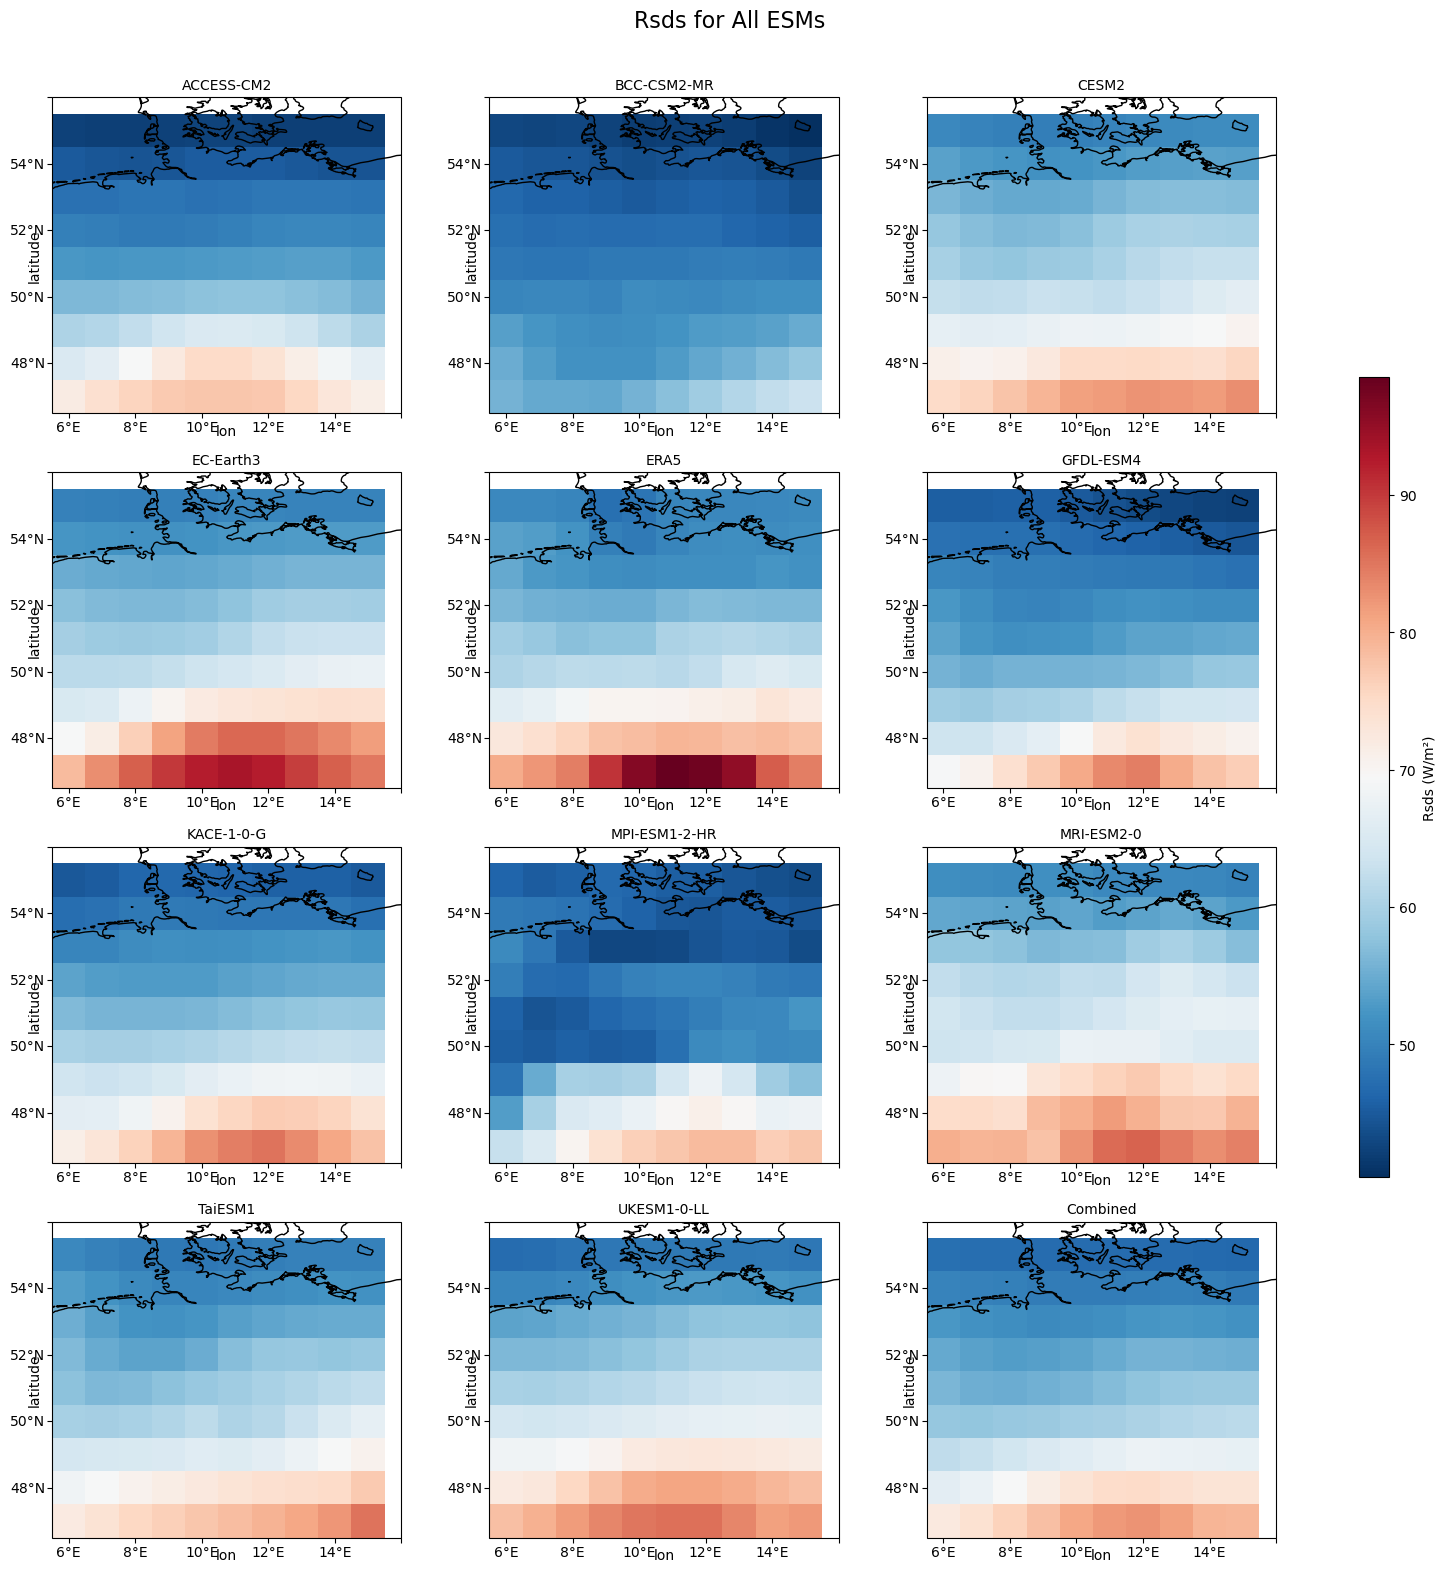

In [8]:
# Define vmin and vmax once
vmin = ts_combined['rsds'].where(ts_combined['rsds'] > 0).min()
vmax = ts_combined['rsds'].max()

# Get ESM list and determine subplot layout
esm_list = ts_combined.ESM.values
n = len(esm_list)

# Choose rows/cols for subplot grid (auto-fit)
ncols = 3
nrows = (n + ncols - 1) // ncols  # ceil division

# Create a big figure
fig, axes = plt.subplots(nrows=nrows, ncols=ncols,
                         figsize=(5 * ncols, 4 * nrows),
                         subplot_kw={'projection': ccrs.PlateCarree()})

# Flatten axes for easier indexing (handles both 1D/2D cases)
axes = axes.flatten()

for i, ESM in enumerate(esm_list):
    # print('ESM:', ESM)
    ds = ts_combined.sel(ESM=ESM)
    
    # Shift longitudes
    new_lon = ((ds['rsds'].lon + 180) % 360) - 180
    da2 = ds['rsds'].assign_coords(lon=new_lon)

    # Plot on respective axis
    ax = axes[i]
    p = da2.plot(ax=ax, transform=ccrs.PlateCarree(),
                 cmap='RdBu_r', add_colorbar=False,
                 vmin=vmin, vmax=vmax)

    ax.coastlines()
    setup_gridlines(ax, deg=2, alpha=0)
    ax.set_title(f'{ESM}', fontsize=10)

# Remove unused axes if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Add one shared colorbar
cbar_ax = fig.add_axes([0.92, 0.25, 0.02, 0.5])  # [left, bottom, width, height]
plt.colorbar(p, cax=cbar_ax, label='Rsds (W/m²)')

fig.suptitle('Rsds for All ESMs', fontsize=16)
plt.tight_layout(rect=[0, 0, 0.9, 0.97])  # Leave space for colorbar and title
plt.show()

## Calculate Anomaly

In [9]:
xr.open_mfdataset(Rsds_files[0]).load()

<xarray.Dataset> Size: 1MB
Dimensions:   (time: 3650, lat: 9, lon: 10)
Coordinates:
  * lat       (lat) int64 72B 47 48 49 50 51 52 53 54 55
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * lon       (lon) int64 80B 6 7 8 9 10 11 12 13 14 15
  * time      (time) datetime64[ns] 29kB 2015-01-01 2015-01-02 ... 2024-12-31
    ESM       <U9 36B 'EC-Earth3'
    run       <U10 40B 'r113i1p1f1'
    ESM_run   <U20 80B 'EC-Earth3_r113i1p1f1'
Data variables:
    rsds      (time, lat, lon) float32 1MB 66.41 71.62 72.53 ... 8.327 10.07
Attributes:
    regrid_method:  bilinear

In [10]:
for rsds_fl in Rsds_files:
    run_time = time.time()
    nc = xr.open_mfdataset(rsds_fl)
    ESM = nc.ESM.values
    run = nc.run.values
    print(f'Processing {ESM}, {run}')
    # if ESM == 'EC-Earth3' and run == 'r131i1p1f1':
    #     print('Skipping EC-Earth3, r131i1p1f1')
    #     continue

    # Filter to only winter months (October to March)
    nc = nc.sel(time=nc.time.dt.month.isin([10, 11, 12, 1, 2, 3]))
    rsds_anomaly = nc.copy()
    # Calculate anomaly
    rsds_anomaly['rsds'] = nc['rsds'] - ts_combined.sel(ESM = ESM)['rsds']

    ts_output = rsds_anomaly.assign_coords(run = run, ESM = ESM, ESM_run = f'{ESM}_{run}')
    ts_output.load()
    ts_output.to_netcdf(f'/climca/people/onennecke/model_output/rsds_anomaly/not_bc/{ESM}_{run}_rsds_anomaly.nc')
    # break


Processing EC-Earth3, r113i1p1f1
Processing EC-Earth3, r124i1p1f1
Processing EC-Earth3, r114i1p1f1
Processing UKESM1-0-LL, r15i1p1f2
Processing EC-Earth3, r127i1p1f1
Processing EC-Earth3, r141i1p1f1
Processing EC-Earth3, r134i1p1f1
Processing MRI-ESM2-0, r2i1p1f1
Processing UKESM1-0-LL, r10i1p1f2
Processing UKESM1-0-LL, r13i1p1f2
Processing UKESM1-0-LL, r2i1p1f2
Processing CESM2, r4i1p1f1
Processing MPI-ESM1-2-HR, r5i1p1f1
Processing EC-Earth3, r130i1p1f1
Processing EC-Earth3, r5i1p1f1
Processing UKESM1-0-LL, r4i1p1f2
Processing UKESM1-0-LL, r12i1p1f2
Processing EC-Earth3, r131i1p1f1
Processing EC-Earth3, r109i1p1f1
Processing ACCESS-CM2, r5i1p1f1
Processing MPI-ESM1-2-HR, r1i1p1f1
Processing EC-Earth3, r146i1p1f1
Processing BCC-CSM2-MR, r1i1p1f1
Processing MPI-ESM1-2-HR, r9i1p1f1
Processing TaiESM1, r1i1p1f1
Processing EC-Earth3, r107i1p1f1
Processing MRI-ESM2-0, r1i1p1f1
Processing EC-Earth3, r144i1p1f1
Processing EC-Earth3, r126i1p1f1
Processing EC-Earth3, r123i1p1f1
Processing ACCE

### Load data again

In [11]:
path = '/climca/people/onennecke/model_output/rsds_anomaly/not_bc/'

files = sorted(glob.glob(os.path.join(path, '*.nc')))
ts_datasets = xr.open_mfdataset(files, combine='nested', concat_dim='ESM_run')

ts_datasets

<xarray.Dataset> Size: 66MB
Dimensions:   (ESM_run: 100, time: 1820, lat: 9, lon: 10)
Coordinates:
  * lat       (lat) int64 72B 47 48 49 50 51 52 53 54 55
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * lon       (lon) int64 80B 6 7 8 9 10 11 12 13 14 15
  * time      (time) datetime64[ns] 15kB 2015-01-01 2015-01-02 ... 2024-12-31
    ESM       (ESM_run) <U13 5kB 'ACCESS-CM2' 'ACCESS-CM2' ... 'UKESM1-0-LL'
    run       (ESM_run) <U10 4kB 'r1i1p1f1' 'r4i1p1f1' ... 'r8i1p1f2' 'r9i1p1f2'
  * ESM_run   (ESM_run) <U23 9kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL_r9i1p...
Data variables:
    rsds      (ESM_run, time, lat, lon) float32 66MB dask.array<chunksize=(1, 1820, 9, 10), meta=np.ndarray>
Attributes:
    regrid_method:  bilinear

### Load cluster data

In [13]:
data = np.load('/home/onennecke/psl_clustering/clustering_results_nbc.npz')
labels = data['labels']
centroids_reshaped = data['centroids_reshaped']

In [14]:
n_esm = ts_datasets.sizes['ESM_run']
n_time = ts_datasets.sizes['time']
labels_esmtime = labels.reshape((n_esm, n_time))

# Create an xarray DataArray mask aligned to ts_datasets coords
mask = xr.DataArray(
    labels_esmtime,
    dims=('ESM_run', 'time'),
    coords={'ESM_run': ts_datasets['ESM_run'], 'time': ts_datasets['time']}
)

In [15]:
# ---------- COMPUTE COMPOSITES ----------
clusters = np.unique(labels)
# We'll store composites in a Dataset with a new 'cluster' dimension
composite_list = []
cluster_sizes = []

for k in clusters:
    # boolean mask for cluster k
    sel = (mask == k)

    # apply mask to anomaly and average over ESM_run & time
    # .where(sel) -> retains dims (ESM_run, time, lat, lon) with NaN where False
    comp = ts_datasets.where(sel).mean(dim=['ESM_run', 'time'], skipna=True)

    # comp is a DataArray lat x lon (with ESM_run/time removed)
    composite_list.append(comp)
    cluster_sizes.append(int(sel.sum().values))  # how many samples fell into this cluster

# concat into one DataArray with cluster dim (keeps lat,lon dims)
composites = xr.concat(composite_list, dim='cluster')
composites = composites.assign_coords(cluster=('cluster', clusters))
# composites dims: cluster x lat x lon

# print("Composite shape:", composites.shape)
# print("Cluster sizes:", cluster_sizes)

In [16]:
composites.compute()

<xarray.Dataset> Size: 2kB
Dimensions:   (cluster: 5, lat: 9, lon: 10)
Coordinates:
  * lat       (lat) int64 72B 47 48 49 50 51 52 53 54 55
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * lon       (lon) int64 80B 6 7 8 9 10 11 12 13 14 15
  * cluster   (cluster) int32 20B 0 1 2 3 4
Data variables:
    rsds      (cluster, lat, lon) float32 2kB -5.105 -5.675 ... 10.24 9.734

In [17]:
# Save composites to a netCDF file
path = '/climca/people/onennecke/model_output/composites/'

composites.to_netcdf(path + 'rsds_anomaly_composites.nc')

In [18]:
# Load composites
path = '/climca/people/onennecke/model_output/composites/'
composites = xr.open_dataset(path + 'rsds_anomaly_composites.nc')
composites.load()

<xarray.Dataset> Size: 2kB
Dimensions:   (cluster: 5, lat: 9, lon: 10)
Coordinates:
  * lat       (lat) int64 72B 47 48 49 50 51 52 53 54 55
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * lon       (lon) int64 80B 6 7 8 9 10 11 12 13 14 15
  * cluster   (cluster) int32 20B 0 1 2 3 4
Data variables:
    rsds      (cluster, lat, lon) float32 2kB -5.105 -5.675 ... 10.24 9.734

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.cm import ScalarMappable
import cartopy.crs as ccrs

/tmp/ipykernel_2959621/2267192093.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


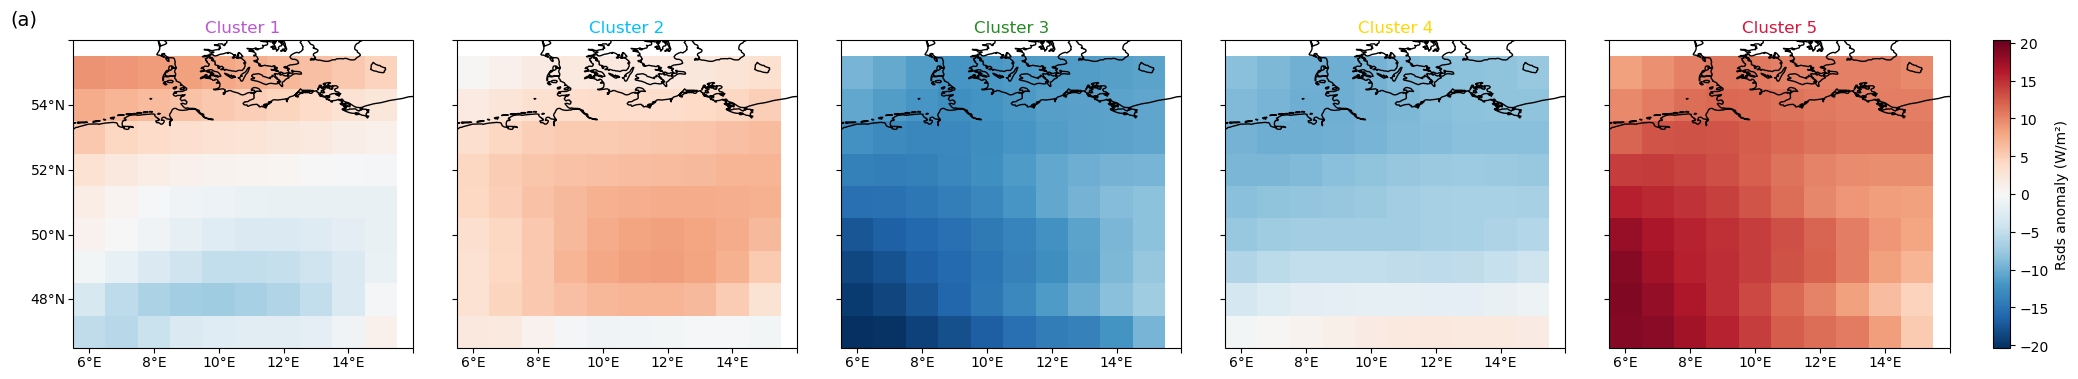

In [20]:

# Colors and desired number of subplots (mimic your example)
cluster_colors = ["mediumorchid", "deepskyblue", "forestgreen", "gold", "crimson"]
max_to_plot = 5  # plot first 5 clusters (as in example)

# Select clusters to plot (handle fewer than 5 gracefully)
clusters_all = np.array(composites['cluster'].values)
n_clusters = len(clusters_all)
n_plot = min(max_to_plot, n_clusters)
clusters_to_plot = clusters_all[:n_plot]

# Compute symmetric color limits (centered on zero)
# Use np.nanmin/np.nanmax on the values (convert to numpy; this is lazy for dask-backed arrays,
# you may want to .compute() beforehand if necessary).
vals = composites['rsds'].values
vmin = np.nanmin(vals)
vmax = np.nanmax(vals)
# make symmetric about zero (like your example)
absmax = max(abs(vmin), abs(vmax))
vmin = -absmax
vmax = absmax

# Levels similar to your example
nlevels = 20
levels = np.linspace(vmin, vmax, nlevels)

# Coordinates for contourf
lons = composites['lon'].values
lats = composites['lat'].values

# -------------------------
# Figure and GridSpec
# -------------------------
ncols = n_plot
nrows = 1
fig = plt.figure(figsize=(5 * ncols, 4))
gs = GridSpec(nrows, ncols + 1, width_ratios=[1] * ncols + [0.05], wspace=0.15)

cmap_name = "RdBu_r"
cmap_used = None

for i, cl in enumerate(clusters_to_plot):
    ax = fig.add_subplot(gs[0, i], projection=ccrs.PlateCarree())

    # select data for this cluster (2D lat x lon)
    da = composites['rsds'].sel(cluster=cl)

    # ensure the array ordering matches lats x lons
    # xarray will align automatically if we pass coords to pcolormesh
    cf = ax.pcolormesh(
        lons, lats, da.values,
        vmin=vmin, vmax=vmax,
        cmap=cmap_name, transform=ccrs.PlateCarree()
    )
    cmap_used = cf.cmap

    ax.coastlines()
    # follow your pattern for gridlines (assumes setup_gridlines() exists)
    if i == 0:
        setup_gridlines(ax, deg=2, alpha=0)
    else:
        setup_gridlines(ax, deg=2, alpha=0, ll=False)

    # Title using provided cluster color list (cycle if fewer/more)
    color = cluster_colors[i % len(cluster_colors)]
    ax.set_title(f"Cluster {int(cl) + 1}", fontsize=12, color=color)

# Add (a) label like your example (position may be adjusted)
fig.text(0.1, 0.92, "(a)", fontsize=14)

# Shared vertical colorbar (use last col in GridSpec)
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=norm, cmap=cmap_used)
sm.set_array([])

cax = fig.add_subplot(gs[0, -1])
cbar = plt.colorbar(sm, cax=cax)
cbar.set_label('Rsds anomaly (W/m²)', fontsize=10)  # replace 'units' with actual units (e.g. m/s)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
